# Federal Reserve Treasury Yield Curve

This notebook provides summary statistics and visualizations for the Federal Reserve's
Treasury yield curve data based on the Gurkaynak, Sack, and Wright (2007) model.

## Data Source

Data is publicly available from the [Federal Reserve](https://www.federalreserve.gov/data/nominal-yield-curve.htm).

## Reference

Gurkaynak, Refet S., Brian Sack, and Jonathan H. Wright. "The US Treasury yield curve: 1961 to the present."
Journal of Monetary Economics 54.8 (2007): 2291-2304.

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import chartbook

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

warnings.filterwarnings("ignore")

## Load the Dataset

The dataset contains zero-coupon Treasury yields for maturities from 1 to 30 years.

In [2]:
# Load the yield curve data
df = pd.read_parquet(DATA_DIR / "ftsfr_treas_yield_curve_zero_coupon.parquet")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (376712, 3)


,unique_id,ds,y
0,SVENY01,1961-06-14,2.9825
1,SVENY01,1961-06-15,2.9941
2,SVENY01,1961-06-16,3.0012
3,SVENY01,1961-06-19,2.9949
4,SVENY01,1961-06-20,2.9833


In [3]:
# Pivot to wide format for analysis
df_wide = df.pivot(index='ds', columns='unique_id', values='y')
print(f"Wide format shape: {df_wide.shape}")
print(f"Tenors: {df_wide.columns.tolist()}")

Wide format shape: (16106, 30)
Tenors: ['SVENY01', 'SVENY02', 'SVENY03', 'SVENY04', 'SVENY05', 'SVENY06', 'SVENY07', 'SVENY08', 'SVENY09', 'SVENY10', 'SVENY11', 'SVENY12', 'SVENY13', 'SVENY14', 'SVENY15', 'SVENY16', 'SVENY17', 'SVENY18', 'SVENY19', 'SVENY20', 'SVENY21', 'SVENY22', 'SVENY23', 'SVENY24', 'SVENY25', 'SVENY26', 'SVENY27', 'SVENY28', 'SVENY29', 'SVENY30']


## Summary Statistics

In [4]:
# Summary statistics for each tenor
summary_stats = df_wide.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
unique_id,,,,,,,,
SVENY01,16106.0,4.809459,3.258954,0.0554,2.303950,4.852237,6.664082,16.4620
SVENY02,16106.0,5.002349,3.204157,0.1020,2.628175,4.866750,6.904200,15.9118
SVENY03,16106.0,5.162044,3.137659,0.1272,2.867450,4.922799,7.083700,15.5746
SVENY04,16106.0,5.298994,3.071867,0.1685,3.068850,5.036641,7.181158,15.3498
SVENY05,16106.0,5.418824,3.011570,0.2218,3.345725,5.192362,7.277300,15.1776
SVENY06,16106.0,5.524497,2.958283,0.2806,3.548400,5.313379,7.348475,15.0611
SVENY07,16106.0,5.617864,2.912150,0.3413,3.711750,5.407650,7.414753,15.0109
SVENY08,13570.0,5.816452,3.074481,0.4020,3.468525,5.739338,7.752375,14.9799
SVENY09,13570.0,5.900859,3.035535,0.4618,3.633750,5.830343,7.782710,14.9572


## Data Coverage

In [5]:
print(f"Date range: {df_wide.index.min()} to {df_wide.index.max()}")
print(f"Number of observations: {len(df_wide)}")
print(f"Missing values per tenor:")
print(df_wide.isnull().sum())

Date range: 1961-06-14 00:00:00 to 2026-01-09 00:00:00
Number of observations: 16106
Missing values per tenor:
unique_id
SVENY01       0
SVENY02       0
SVENY03       0
SVENY04       0
SVENY05       0
SVENY06       0
SVENY07       0
SVENY08    2536
SVENY09    2536
SVENY10    2536
SVENY11    2597
SVENY12    2597
SVENY13    2597
SVENY14    2597
SVENY15    2597
SVENY16    4995
SVENY17    4995
SVENY18    4995
SVENY19    4995
SVENY20    4995
SVENY21    6090
SVENY22    6090
SVENY23    6090
SVENY24    6090
SVENY25    6090
SVENY26    6090
SVENY27    6090
SVENY28    6090
SVENY29    6090
SVENY30    6090
dtype: int64


## Current Yield Curve

The most recent yield curve snapshot.

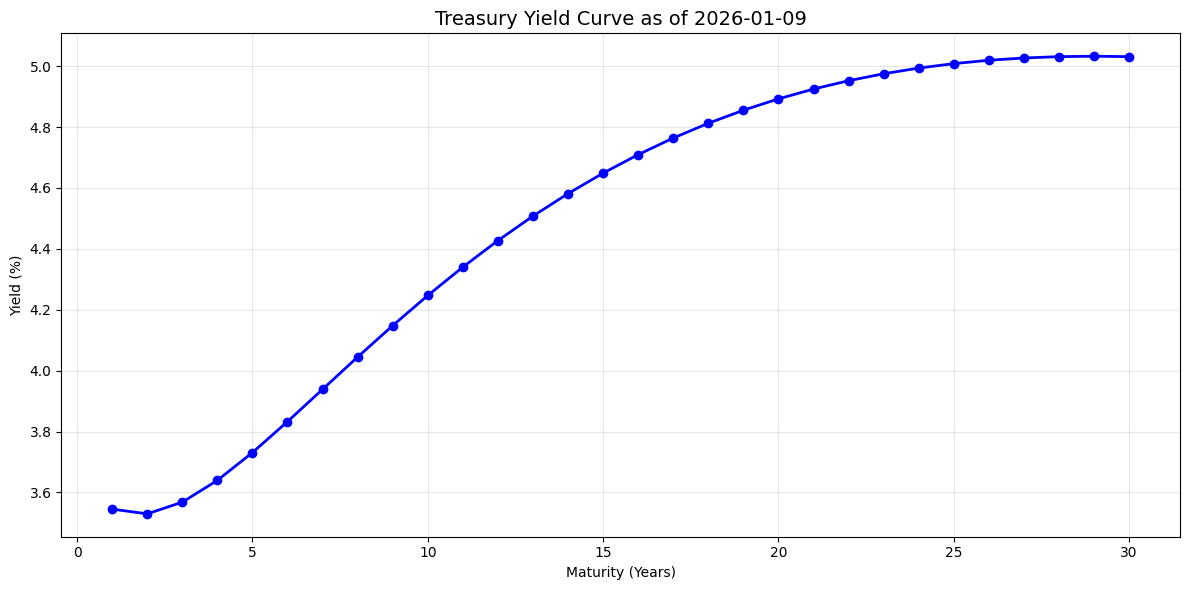

In [6]:
# Get the most recent yield curve
latest_date = df_wide.index.max()
latest_curve = df_wide.loc[latest_date].dropna()

# Extract maturity in years from tenor names (e.g., SVENY01 -> 1)
maturities = [int(col.replace('SVENY', '')) for col in latest_curve.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(maturities, latest_curve.values, 'b-o', linewidth=2, markersize=6)
ax.set_title(f'Treasury Yield Curve as of {latest_date.strftime("%Y-%m-%d")}', fontsize=14)
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

## Historical Yield Curve Evolution

Time series of selected tenors.

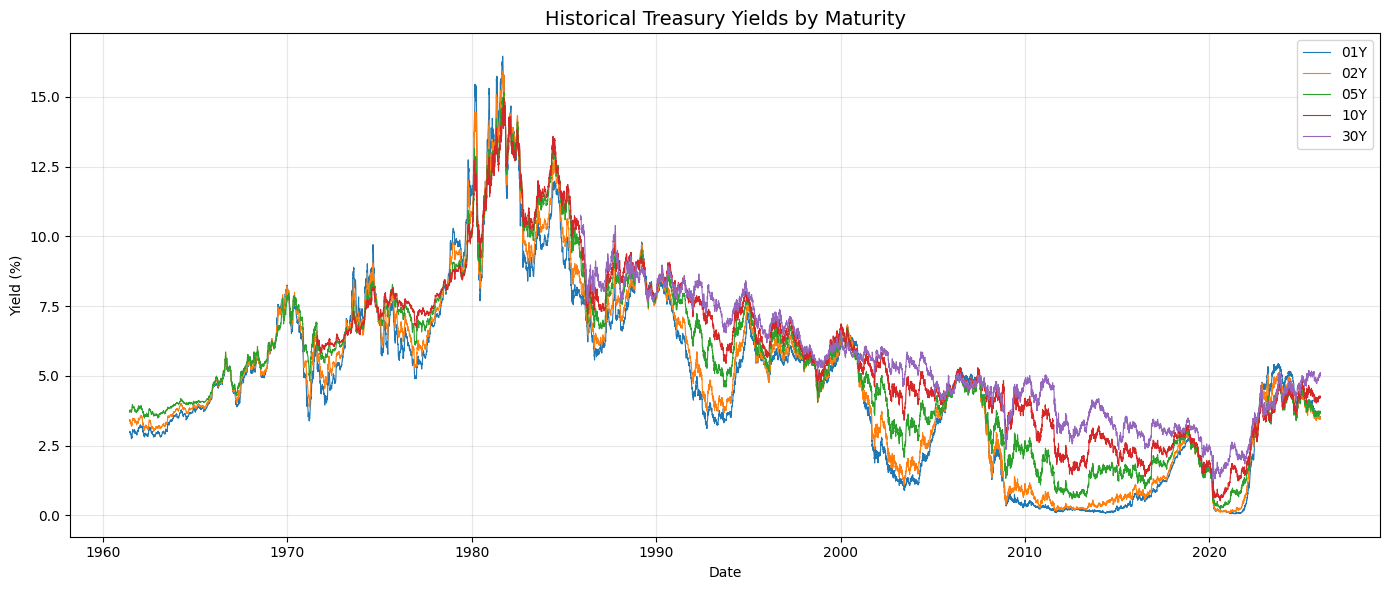

In [7]:
# Select key tenors for visualization
key_tenors = ['SVENY01', 'SVENY02', 'SVENY05', 'SVENY10', 'SVENY30']
available_tenors = [t for t in key_tenors if t in df_wide.columns]

fig, ax = plt.subplots(figsize=(14, 6))
for tenor in available_tenors:
    label = tenor.replace('SVENY', '') + 'Y'
    ax.plot(df_wide.index, df_wide[tenor], label=label, linewidth=0.8)

ax.set_title('Historical Treasury Yields by Maturity', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Yield (%)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Yield Curve Slope (10Y - 2Y Spread)

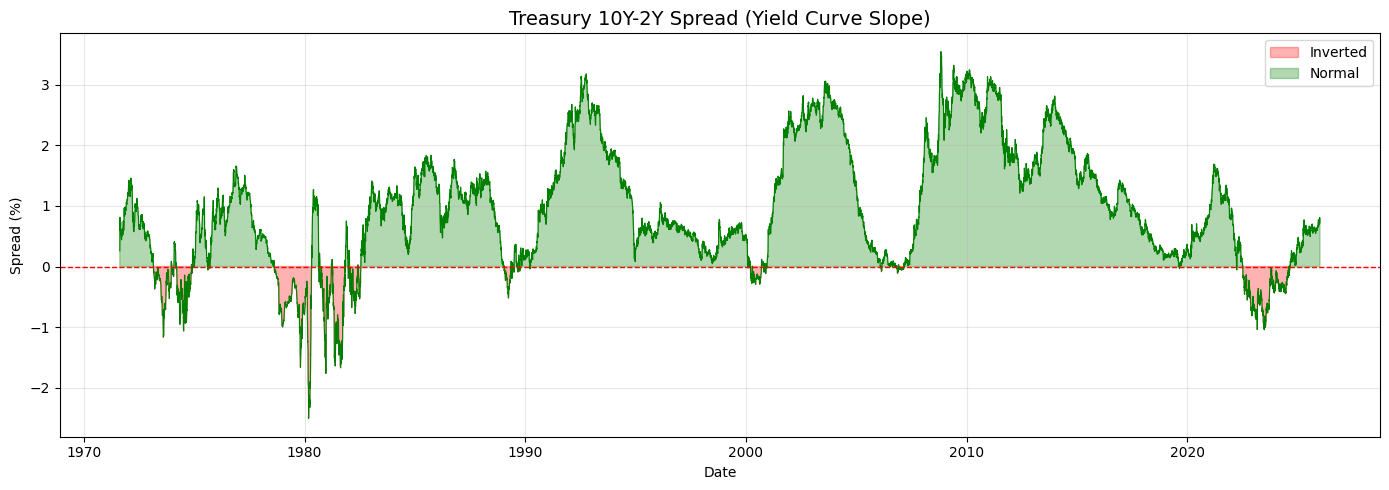


Spread Statistics:
  Mean: 0.93%
  Std: 1.00%
  Min: -2.51%
  Max: 3.55%
  Current: 0.72%


In [8]:
if 'SVENY10' in df_wide.columns and 'SVENY02' in df_wide.columns:
    spread_10_2 = df_wide['SVENY10'] - df_wide['SVENY02']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(spread_10_2.index, spread_10_2.values, linewidth=0.8, color='green')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.fill_between(spread_10_2.index, 0, spread_10_2.values,
                    where=(spread_10_2 < 0), color='red', alpha=0.3, label='Inverted')
    ax.fill_between(spread_10_2.index, 0, spread_10_2.values,
                    where=(spread_10_2 >= 0), color='green', alpha=0.3, label='Normal')
    ax.set_title('Treasury 10Y-2Y Spread (Yield Curve Slope)', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Spread (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nSpread Statistics:")
    print(f"  Mean: {spread_10_2.mean():.2f}%")
    print(f"  Std: {spread_10_2.std():.2f}%")
    print(f"  Min: {spread_10_2.min():.2f}%")
    print(f"  Max: {spread_10_2.max():.2f}%")
    print(f"  Current: {spread_10_2.iloc[-1]:.2f}%")

## Correlation Matrix

Correlation between yields at different maturities.

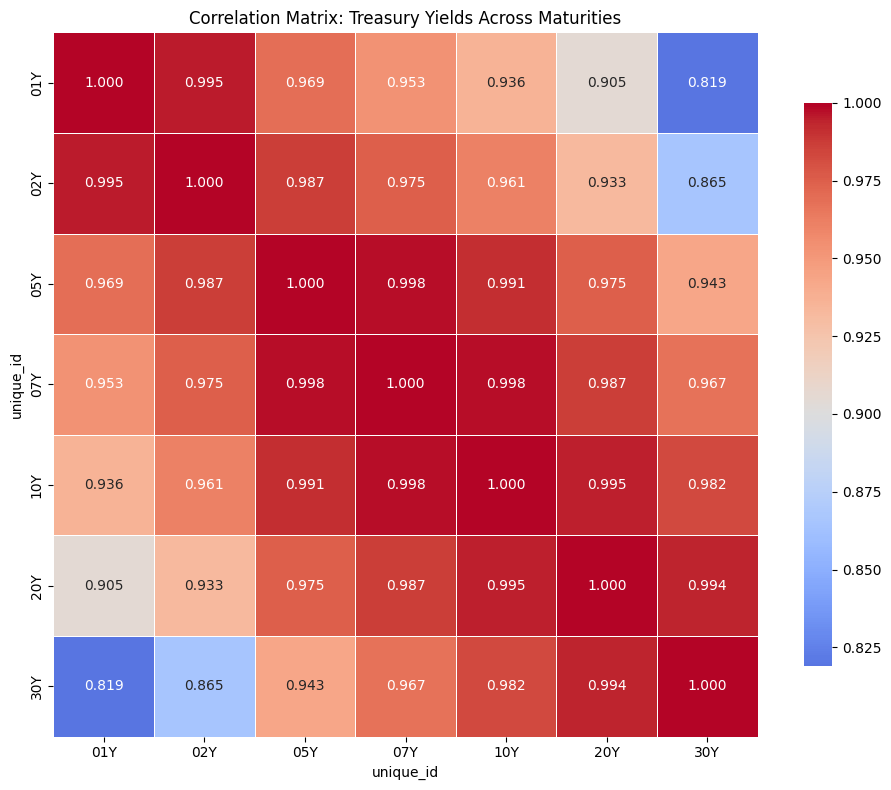

In [9]:
# Select subset of tenors for correlation
corr_tenors = ['SVENY01', 'SVENY02', 'SVENY05', 'SVENY07', 'SVENY10', 'SVENY20', 'SVENY30']
available_corr = [t for t in corr_tenors if t in df_wide.columns]
corr_matrix = df_wide[available_corr].corr()

# Rename for display
rename_dict = {t: t.replace('SVENY', '') + 'Y' for t in available_corr}
corr_matrix = corr_matrix.rename(index=rename_dict, columns=rename_dict)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0.9,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix: Treasury Yields Across Maturities', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

This dataset provides daily zero-coupon Treasury yields estimated using the
Gurkaynak, Sack, and Wright (2007) model. The yields cover maturities from 1 to 30 years
and are widely used in fixed income research and practice.

Key applications:
- Yield curve analysis and term structure modeling
- Fixed income derivatives pricing
- Monetary policy analysis
- Risk-free rate estimation